i decided to use transformer-based model for the emotion classification task and after search for a while i found roberta-base model the most recommend model for classification tasks , so i used it here

# Importing Libraries

In [ ]:
# !pip install --upgrade datasets transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 86.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2


In [ ]:
import torch
import torch.nn as nn
from transformers import Trainer, TrainingArguments
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Model & Dataset Loading

In [3]:
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

model = AutoModelForSequenceClassification.from_pretrained("FacebookAI/roberta-base", num_labels=6)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
dataset = load_dataset("dair-ai/emotion")
dataset

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

# Exploring The Dataset


The dataset contains the following features:

| Field Name | Data Type | Description |
| :--- | :--- | :--- |
| `text` | String | The input text sequence to be classified. |
| `label` | Integer | The target emotion classification label. |


The `label` field maps to the following six emotional states:

* **0**: Sadness
* **1**: Joy
* **2**: Love
* **3**: Anger
* **4**: Fear
* **5**: Surprise

In [5]:
df_train = dataset['train'].to_pandas()
df_train.head(10)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,1
9,i feel romantic too,2


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


In [7]:
df_train.isna().sum()

,0
text,0
label,0


In [8]:
df_train.duplicated().sum()

np.int64(1)

In [9]:
df_train.drop_duplicates(inplace=True)

In [10]:
df_train['label'].value_counts()

,count
label,
1,5361
0,4666
3,2159
4,1937
2,1304
5,572


### Class Distribution Analysis

An analysis of the dataset reveals a significant class imbalance across the six emotional categories. The dominant classes are **Joy** ($1$) and **Sadness** ($0$), while **Surprise** ($5$) represents the minority class.

| Label ID | Emotion | Sample Count | Percentage (%) |
| :---: | :--- | :---: | :---: |
| **1** | Joy | 5,362 | 33.51% |
| **0** | Sadness | 4,666 | 29.16% |
| **3** | Anger | 2,159 | 13.50% |
| **4** | Fear | 1,937 | 12.11% |
| **2** | Love | 1,304 | 8.15% |
| **5** | Surprise | 572 | 3.58% |
| **Total** | | **16,000** | **100.00%** |

---

### Mitigating Class Imbalance

To prevent the RoBERTa model from biasing toward the majority classes (`joy` and `sadness`), the following strategies will be considered during the training phase:

1. **Evaluation Metrics:** Rely on **Macro F1-Score** and **Weighted F1-Score** instead of standard accuracy to evaluate model performance fairly across all classes.
2. **Loss Function Adjustment:** Implement class weights in the cross-entropy loss function to penalize misclassifications of minority classes (like `surprise` and `love`) more heavily.

In [11]:
emotion_mapping = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

# Data Quality & Preprocessing


In [12]:
df_train.sample(50)

,text,label
15521,i am feeling convinced by the argument extende...,1
4884,i feel very honored to be on the shortlist and...,1
11956,i feel lethargic and unmotivated in the mornin...,0
5844,i ask you to trust this and to celebrate not t...,2
6100,im most afraid of i already feel slightly out ...,3
12738,i invariably feel very optimistic and focused,1
15285,i feel strongly impressed that there must be s...,5
15943,i believe the most readers feel impressed by t...,5
642,i was left feeling discouraged and hopeless on...,0
5750,i love those ted talks i feel intimidated more...,4


Following a exploratory data analysis (EDA), it was determined that the dataset is clean, structurally sound, and requires no further preprocessing or text normalization. 

The dataset exhibits the following characteristics:
* **No Missing Values:** There are no null or missing entries within the `text` or `label` fields.
* **Pre-cleaned Text:** The text sequences are already normalized (e.g., consistent casing, appropriate spacing, and handled special characters), making them immediately compatible with the tokenizer.
* **Ready for Pipeline:** The data is fully prepared to be fed directly into the RoBERTa tokenization and training pipeline.

# Model Preparation & Training

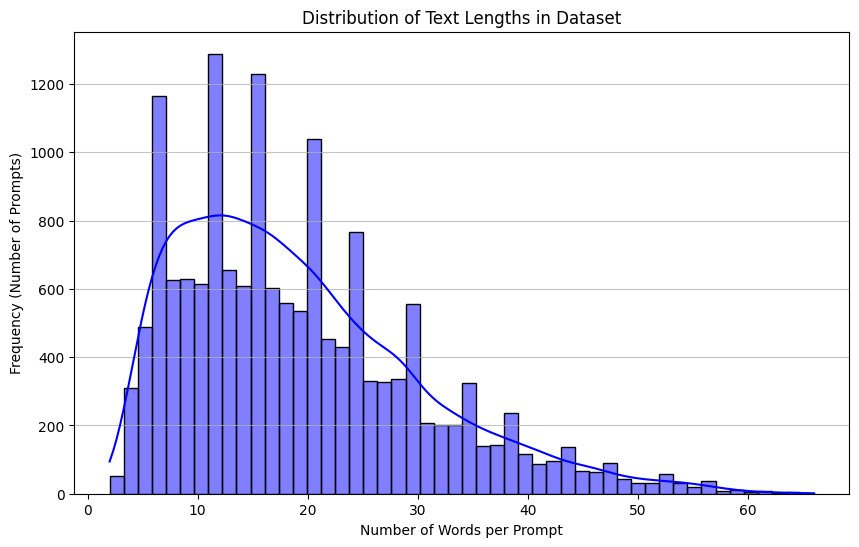

--- Text Length Statistics ---
Average length:  19 words
90th percentile: 35 words
95th percentile: 41 words
99th percentile: 52 words
Absolute Max:    66 words


In [13]:
word_count = df_train['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(word_count, bins=50, kde=True, color='blue')
plt.title('Distribution of Text Lengths in Dataset')
plt.xlabel('Number of Words per Prompt')
plt.ylabel('Frequency (Number of Prompts)')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("--- Text Length Statistics ---")
print(f"Average length:  {word_count.mean():.0f} words")
print(f"90th percentile: {np.percentile(word_count, 90):.0f} words")
print(f"95th percentile: {np.percentile(word_count, 95):.0f} words")
print(f"99th percentile: {np.percentile(word_count, 99):.0f} words")
print(f"Absolute Max:    {word_count.max()} words")

An analysis of the text sequence lengths was conducted to determine the optimal configuration for the tokenizer. The key statistics are as follows:
* **Average length:** 19 words
* **90th percentile:** 38 words

Based on these findings, a maximum sequence length of **128 tokens** (`max_length=128`) was selected for the RoBERTa tokenizer.

In [14]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        padding="max_length",
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )

In [15]:
hf_train = dataset['train']
hf_eval = dataset['validation']

tokenized_train_dataset = hf_train.map(tokenize_function, batched=True)
tokenized_eval_dataset = hf_eval.map(tokenize_function, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
columns_to_remove = ["text"]
if "__index_level_0__" in tokenized_train_dataset.column_names:
    columns_to_remove.append("__index_level_0__")

tokenized_train_dataset = tokenized_train_dataset.remove_columns(columns_to_remove)
tokenized_eval_dataset = tokenized_eval_dataset.remove_columns(columns_to_remove)

tokenized_train_dataset = tokenized_train_dataset.rename_column("label", "labels")
tokenized_eval_dataset = tokenized_eval_dataset.rename_column("label", "labels")

tokenized_train_dataset.set_format("torch")
tokenized_eval_dataset.set_format("torch")

### Class Weights

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
train_labels = df_train['label'].tolist()

class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(train_labels), 
    y=train_labels
)

weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [19]:
weights_tensor

tensor([0.5715, 0.4974, 2.0449, 1.2351, 1.3766, 4.6617], device='cuda:0')

### Weighted Loss Function

In [ ]:
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

### Model Training

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    
    return {
        'accuracy': acc,
        'f1_macro': f1,
        'precision_macro': precision,
        'recall_macro': recall
    }

In [24]:
training_args = TrainingArguments(
    output_dir="./roberta-emotion-classifier",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy="epoch", 
    logging_steps=50,
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_eval_dataset,
    compute_metrics=compute_metrics  
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,1.147747,1.075744,0.371000,0.255037,0.335575,0.475562
2,0.565916,0.508454,0.892500,0.743835,0.719172,0.777031
3,0.244366,0.311804,0.921500,0.896512,0.884098,0.912240


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.8333637418746949, metrics={'train_runtime': 1362.3946, 'train_samples_per_second': 35.232, 'train_steps_per_second': 2.202, 'total_flos': 3157446057984000.0, 'train_loss': 0.8333637418746949, 'epoch': 3.0})

In [ ]:
training_args = TrainingArguments(
    output_dir="./roberta-emotion-classifier",
    num_train_epochs=5,                 
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",              
    logging_steps=50,
    load_best_model_at_end=True,       
    metric_for_best_model="f1_macro",
    greater_is_better=True
)

trainer = WeightedLossTrainer(
    model=model, 
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_eval_dataset,
    compute_metrics=compute_metrics
)

trainer.train(resume_from_checkpoint="./roberta-emotion-classifier/checkpoint-3000")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
4,0.312130,0.315061,0.922500,0.894886,0.873820,0.926027
5,0.168652,0.266797,0.926000,0.902323,0.882310,0.930857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.1114758586883545, metrics={'train_runtime': 851.9023, 'train_samples_per_second': 93.907, 'train_steps_per_second': 5.869, 'total_flos': 5262410096640000.0, 'train_loss': 0.1114758586883545, 'epoch': 5.0})

# Model Evaluation

In [ ]:
hf_test = dataset['test']

tokenized_test_dataset = hf_test.map(tokenize_function, batched=True)

columns_to_remove = ["text"]
if "__index_level_0__" in tokenized_test_dataset.column_names:
    columns_to_remove.append("__index_level_0__")

tokenized_test_dataset = tokenized_test_dataset.remove_columns(columns_to_remove)
tokenized_test_dataset = tokenized_test_dataset.rename_column("label", "labels")
tokenized_test_dataset.set_format("torch")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print("--- Final Model Test Results ---")
final_results = trainer.evaluate(eval_dataset=tokenized_test_dataset) 

for key, value in final_results.items():
    print(f"{key}: {value:.4f}")

--- Final Model Test Results ---


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.168652,0.280837,5,0.922500,0.884533,0.861902,0.922074


eval_loss: 0.2808
eval_accuracy: 0.9225
eval_f1_macro: 0.8845
eval_precision_macro: 0.8619
eval_recall_macro: 0.9221


# Save Model


In [35]:
final_save_path = "./final_model_5_epochs"
trainer.save_model(final_save_path)
tokenizer.save_pretrained(final_save_path) 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_model_5_epochs/tokenizer_config.json',
 './final_model_5_epochs/tokenizer.json')